## Coucou moi c'est Tim :), voici mon premier projet perso !

### C'est un réseau de neurones que j'ai entrainé afin de détecter des cancers du poumon. Ce type d'IA est déjà utilisé dans la médecine moderne. Cependant, je voulais faire ma petite version personnelle puisque je cherche à travailler dans le médical plus tard (IA/Cyber/Data etc.).

### (VOUS POUVEZ VOIR UN EXEMPLE DE RESULTAT DIRECTEMENT TOUT EN BAS)

### Vous pouvez suivre les étapes du projet via le texte et les blocs de code :) (Cependant vous ne pourrez pas le faire fonctionner, car il a besoin de mon API Kaggle)

### Etape 0 : Chargement de l'environnement temporaire quand je reviens sur collab

### (colab sauvegarde rien, tout les blocs de codes suivants servent à recharger les imports et les simulations que je sauvergarde dans mon drive)


récupération des fichiers

In [ ]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/Data/train",
    image_size=(224,224),
    batch_size=32,
    label_mode="categorical"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/Data/valid",
    image_size=(224,224),
    batch_size=32,
    label_mode="categorical"
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/Data/test",
    image_size=(224,224),
    batch_size=32,
    label_mode="categorical"
)

Found 613 files belonging to 4 classes.
Found 72 files belonging to 4 classes.
Found 315 files belonging to 4 classes.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


chargement des anciennes simulations

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
model = tf.keras.models.load_model("/content/drive/MyDrive/lung_model.keras")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Etape 1 : Liaison de colab avec Kaggle
- Création de l'API sur Kaggle
- Transfert de la base de donnée d'imagerie médicale

In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import userdata
kaggle_key = userdata.get('API_KAGGLE (et oui la mienne est privée :)')

In [ ]:
from google.colab import files
files.upload()

{}

In [ ]:
!kaggle datasets download -d mohamedhanyyy/chest-ctscan-images
!unzip chest-ctscan-images.zip

In [ ]:
import json, os

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": "pataplouf", "key": kaggle_key}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

In [ ]:
!kaggle datasets list

In [ ]:
!kaggle datasets download -d mohamedhanyyy/chest-ctscan-images

Dataset URL: https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images
License(s): ODbL-1.0
  0% 0.00/119M [00:00<?, ?B/s]
100% 119M/119M [00:00<00:00, 1.50GB/s]


J'ai téléchargé le DataSet de CT-Scan de poumons avec le lien Kaggle.
Dans l'étape suivante, j'ai dézippé le Dataset, et j'y ai maintenant directement accès depuis colab !

In [ ]:
!unzip chest-ctscan-images.zip

### Etape 2 : Plus 1000 photos ! Analysons et trions toutes ces radios
- Analyse des classes
- Comptage du nombre d'images par classe
- Chargement des images
- Normalisation, contruction et compilation

In [ ]:
import os

base_path = "/content"

for root, dirs, files in os.walk(base_path):
    print(root)
    break

/content


On analyse le dossier principal :

In [ ]:
data_path = "/content/Data"

for folder in os.listdir(data_path):
    print(folder)

valid
test
train


Ensuite, j'ai compté le nombre d'images pour chaque classe avec une boucle for

In [ ]:
train_path = "/content/Data/valid"

for class_name in os.listdir(train_path):
    class_path = os.path.join(train_path, class_name)
    print(class_name, ":", len(os.listdir(class_path)))

normal : 13
adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib : 23
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa : 15
large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa : 21


In [ ]:
train_path = "/content/Data/test"

for class_name in os.listdir(train_path):
    class_path = os.path.join(train_path, class_name)
    print(class_name, ":", len(os.listdir(class_path)))

large.cell.carcinoma : 51
normal : 54
adenocarcinoma : 120
squamous.cell.carcinoma : 90


In [ ]:
train_path = "/content/Data/train"

for class_name in os.listdir(train_path):
    class_path = os.path.join(train_path, class_name)
    print(class_name, ":", len(os.listdir(class_path)))

normal : 148
adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib : 195
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa : 155
large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa : 115


Maintenant:
- j'importe TensorFlow, et l'API Keras. Il contient tout les outils nécéssaires pour entraîner un réseau de neurones
- je definis la taille des images, et le nombres d'images traitées simultanément
- Lance une fonction pour chaque classe, elle mélange les données pour un jeu d'entraînement

In [ ]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/Data/train",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/Data/valid",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/Data/test",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 613 files belonging to 4 classes.
Found 72 files belonging to 4 classes.
Found 315 files belonging to 4 classes.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


Normalisation

AUTOTUNE va laisser TensorFlow choisir la taille de buffer optimale en fonction de mon ordi

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


Construction

J'utilise DenseNet, ca va améliorer le modèle de programation car c'est pré-entaîné avec 1,4M de données

In [ ]:
base_model = tf.keras.applications.DenseNet121(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from tensorflow.keras import layers, models

In [ ]:
inputs = tf.keras.Input(shape=(224,224,3))
x = tf.keras.applications.densenet.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(4, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         4,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,041,604 (26.86 MB)

 Trainable params: 4,100 (16.02 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

## Résumé pour la classification des images :
- Entrée : image 224×224×3.

- Prétraitement : normalisation spécifique DenseNet.

- Extraction de caractéristiques : DenseNet121 gelé.

- Pooling global : transforme les cartes en vecteur.

- Régularisation : Dropout à 30 %.

- Classification : couche dense softmax vers 4 classes.

- Compilation avec Adam

Compilation

J'utilise Adam, c'est un optimiser connu qui adapte le taux d’apprentissage pour chaque paramètre

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)


## Etape 3 : Entraînement !!!

Phase 1 : Elle a pris 23min


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 138s 6s/step - accuracy: 0.3035 - auc: 0.5571 - loss: 1.7652 - val_accuracy: 0.4444 - val_auc: 0.7373 - val_loss: 1.1664
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 152s 7s/step - accuracy: 0.4771 - auc: 0.7358 - loss: 1.2202 - val_accuracy: 0.5000 - val_auc: 0.8151 - val_loss: 1.0009
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 126s 6s/step - accuracy: 0.5468 - auc: 0.8118 - loss: 1.0235 - val_accuracy: 0.5278 - val_auc: 0.8200 - val_loss: 0.9778
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 125s 6s/step - accuracy: 0.5829 - auc: 0.8345 - loss: 0.9753 - val_accuracy: 0.5139 - val_auc: 0.8282 - val_loss: 0.9416
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 133s 6s/step - accuracy: 0.5914 - auc: 0.8525 - loss: 0.9063 - val_accuracy: 0.6389 - val_auc: 0.8655 - val_loss: 0.8556
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 125s 6s/step - accuracy: 0.5981 - auc: 0.8727 - loss: 0.8419 - val_accuracy: 0.6250 - val_auc: 0.8791 - val_loss: 0.8191
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 124s 6s/

## Interpretation graphique sur Excel :

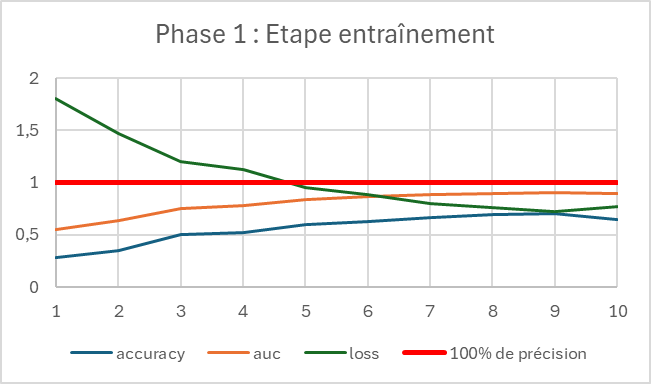

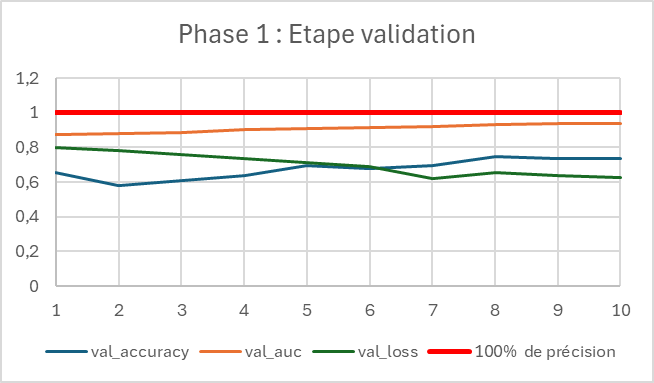

61% d'accurracy pour la validation, c'est peu mais c'est que le début, et c'est normal avec 4 classes et un petit dataset (1000 images c'est bcp, mais pour entrainer mon réseau c'est moyen)

Par contre 87% d'AUC c'est exceptionel ! Ca veut dire que le modèle sépare bien les classes :)

Comme on peut le voir sur le shéma ci-dessous, je vais devoir baisser le learning rate pour gagner en précision. C'est parti pour la phase 2 :)
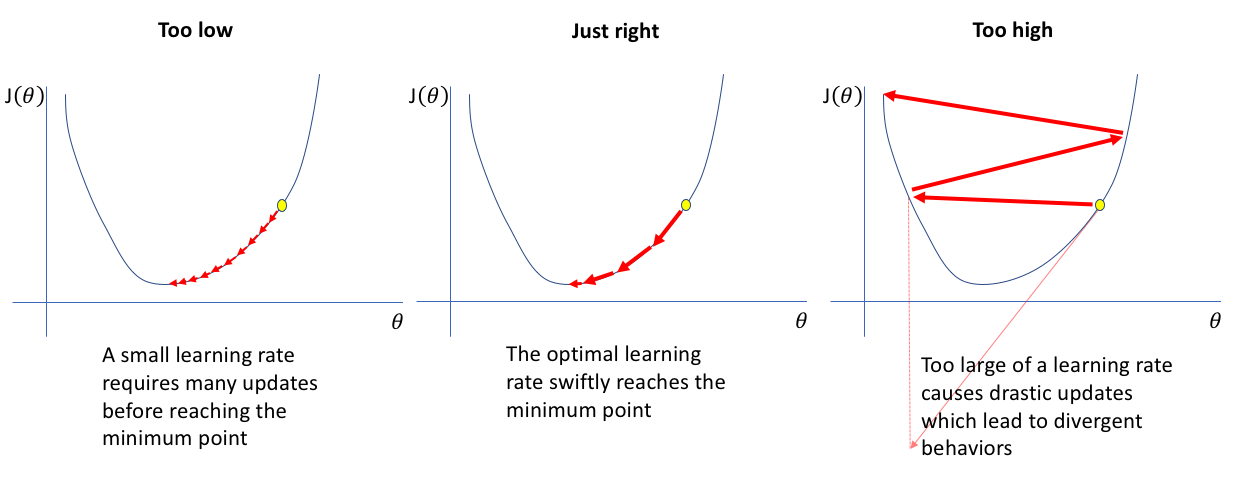

In [ ]:
base_model.trainable = True

Je le fais passer de 1e-3 à 1e-5

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

Phase 2 : Elle a pris 1h16 c'etait lonnnnnnnng (a cause du learning rate)

In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 145s 7s/step - accuracy: 0.7237 - auc: 0.9223 - loss: 0.6652 - val_accuracy: 0.7222 - val_auc: 0.9069 - val_loss: 0.7431
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 135s 6s/step - accuracy: 0.7154 - auc: 0.9198 - loss: 0.6789 - val_accuracy: 0.7222 - val_auc: 0.9060 - val_loss: 0.7445
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 135s 6s/step - accuracy: 0.7428 - auc: 0.9271 - loss: 0.6534 - val_accuracy: 0.7083 - val_auc: 0.9044 - val_loss: 0.7471
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 114s 6s/step - accuracy: 0.7402 - auc: 0.9287 - loss: 0.6443 - val_accuracy: 0.7083 - val_auc: 0.9035 - val_loss: 0.7488
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 142s 6s/step - accuracy: 0.7477 - auc: 0.9263 - loss: 0.6490 - val_accuracy: 0.6944 - val_auc: 0.9035 - val_loss: 0.7497
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 150s 6s/step - accuracy: 0.7391 - auc: 0.9329 - loss: 0.6342 - val_accuracy: 0.6944 - val_auc: 0.9027 - val_loss: 0.7507
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 122s 6s/

## Interpretation graphique sur Excel :

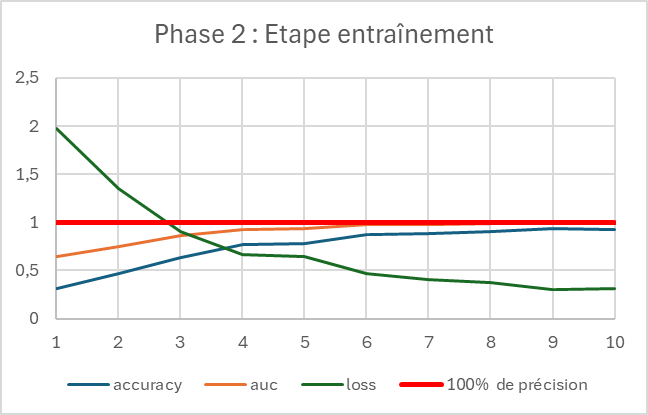

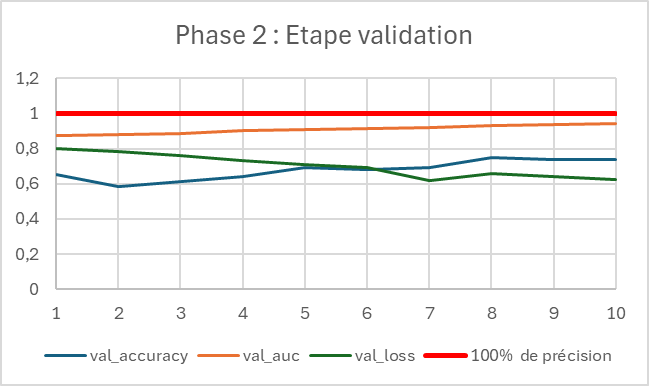

In [ ]:
model.save("/content/drive/MyDrive/lung_model.keras")


### Etape 4 :
- Confusion matrix ( pour voir quelles classes sont confondues )
- F1-Score par classe ( pour vérifier si l'accuracy globale cahce pas des problèmes)

Je remets les imports pour les excecuter si j'ai fermé la session entre temps

In [ ]:
import tensorflow as tf
import numpy as np
import os

Je crée une variable avec le nom des classes

In [ ]:
class_names = ['normal',
               'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
               'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa',
               'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa']

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


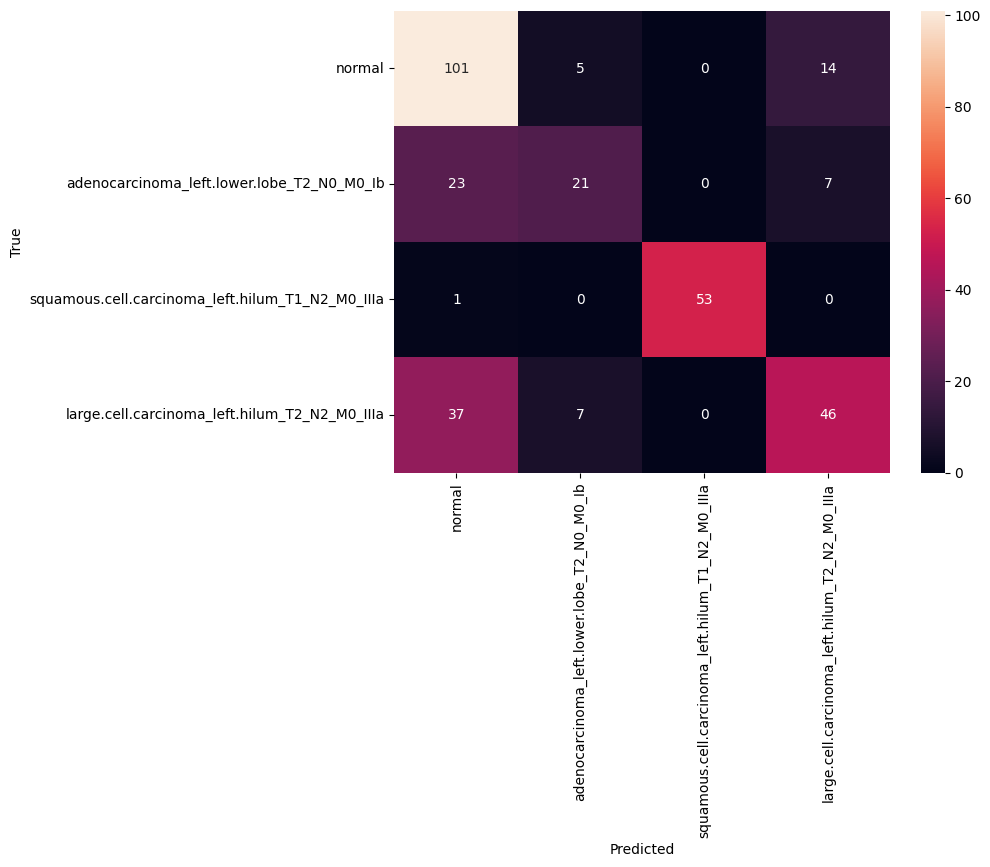

                                                  precision    recall  f1-score   support

                                          normal       0.62      0.84      0.72       120
      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.64      0.41      0.50        51
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       1.00      0.98      0.99        54
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.69      0.51      0.59        90

                                        accuracy                           0.70       315
                                       macro avg       0.74      0.69      0.70       315
                                    weighted avg       0.71      0.70      0.69       315



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Prédictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

## Ce que j'interprete de cette matrice :

- Score global de 70%
- Mon reseau dinstingue mal l'adenocarcinoma (21/51 ca fait 41% de bonne réponse c'est pas dingue ( c'est nul ) )
- Squamous carcinoma presque sans faute ! (53/54)
- Il va falloir réentrainer je crois bien

### Etape 5 : Phase d'optimisation
- Caclcul des Class Weight (corriger le déséquilibre)
- Recompilation avec un learning rate de 1e-4
- Et c'est parti phase d'entraînement 3 :)

On recharge tout :

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

In [ ]:
base_model = tf.keras.applications.DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Inputs + paramètres ( pour la milième fois parce que j'oublie de le recharger a chaque fois )

In [ ]:
inputs = tf.keras.Input(shape=(224,224,3))
x = tf.keras.applications.densenet.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(4, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC()]
)

In [ ]:
print(train_ds)
print(val_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>


Calcul des Class Weight :

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y_train = np.concatenate([y for x, y in train_ds], axis=0)
y_train = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(0.7858974358974359), 1: np.float64(1.3326086956521739), 2: np.float64(1.035472972972973), 3: np.float64(0.9887096774193549)}


CallBacks intelligents :

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-7
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/lung_model_optimized.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

Phase 3 : Elle a pris 40min (jsp pourquoi c'etait si court)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 164s 7s/step - accuracy: 0.2390 - auc: 0.4794 - loss: 1.9542 - val_accuracy: 0.3056 - val_auc: 0.5240 - val_loss: 1.5520 - learning_rate: 1.0000e-04
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 126s 6s/step - accuracy: 0.2440 - auc: 0.4915 - loss: 1.7501 - val_accuracy: 0.3194 - val_auc: 0.5929 - val_loss: 1.4040 - learning_rate: 1.0000e-04
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 128s 6s/step - accuracy: 0.2763 - auc: 0.5208 - loss: 1.6940 - val_accuracy: 0.3472 - val_auc: 0.6243 - val_loss: 1.3617 - learning_rate: 1.0000e-04
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 132s 7s/step - accuracy: 0.3168 - auc: 0.5626 - loss: 1.6465 - val_accuracy: 0.3333 - val_auc: 0.6471 - val_loss: 1.3306 - learning_rate: 1.0000e-04
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 133s 7s/step - accuracy: 0.3425 - auc: 0.5975 - loss: 1.4833 - val_accuracy: 0.3611 - val_auc: 0.6619 - val_loss: 1.3091 - learning_rate: 1.0000e-04
Epoch 6/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 135s 6s/step - accuracy: 0.

Ok début des problèmes c'est moins bon qu'avant et j'ai aucune idée de pourquoi... youpi


Sauvegarde de ce modele dans mon drive

In [ ]:
model.save("/content/drive/MyDrive/lung_model_optimized_final.keras")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/lung_model_optimized_final.keras"
)

Recharge du bon modèle

In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/lung_model.keras"
)
model.summary()
model.evaluate(val_ds)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         4,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,049,806 (26.89 MB)

 Trainable params: 4,100 (16.02 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

 Optimizer params: 8,202 (32.04 KB)

3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.6684 - auc: 0.8868 - loss: 0.7921


[0.7518090009689331, 0.6805555820465088, 0.9021990299224854]

Compilation d'un nouveau modèle, learning rate plus faible, en esperant que ce soit moins cataclysmique que le précédent

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC()]
)

Phase 4 : Ca passe ou ca casse (50min)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 179s 8s/step - accuracy: 0.2909 - auc_1: 0.5354 - loss: 1.9240 - val_accuracy: 0.4167 - val_auc_1: 0.7084 - val_loss: 1.2086 - learning_rate: 0.0010
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 134s 7s/step - accuracy: 0.3916 - auc_1: 0.6971 - loss: 1.2998 - val_accuracy: 0.4306 - val_auc_1: 0.7545 - val_loss: 1.0993 - learning_rate: 0.0010
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 142s 7s/step - accuracy: 0.5344 - auc_1: 0.7726 - loss: 1.1281 - val_accuracy: 0.5417 - val_auc_1: 0.8311 - val_loss: 0.9469 - learning_rate: 0.0010
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 130s 6s/step - accuracy: 0.5301 - auc_1: 0.7949 - loss: 1.0791 - val_accuracy: 0.5139 - val_auc_1: 0.8478 - val_loss: 0.8991 - learning_rate: 0.0010
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 133s 7s/step - accuracy: 0.5221 - auc_1: 0.8095 - loss: 1.0155 - val_accuracy: 0.6111 - val_auc_1: 0.8610 - val_loss: 0.8542 - learning_rate: 0.0010
Epoch 6/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 124s 6s/step - accuracy: 0.

Matrice de confusion pour cette phase d'entrainement (Parce que pourquoi pas)

Classes (Types de cancers) :

In [ ]:
class_names = ['normal',
               'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
               'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa',
               'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa']

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


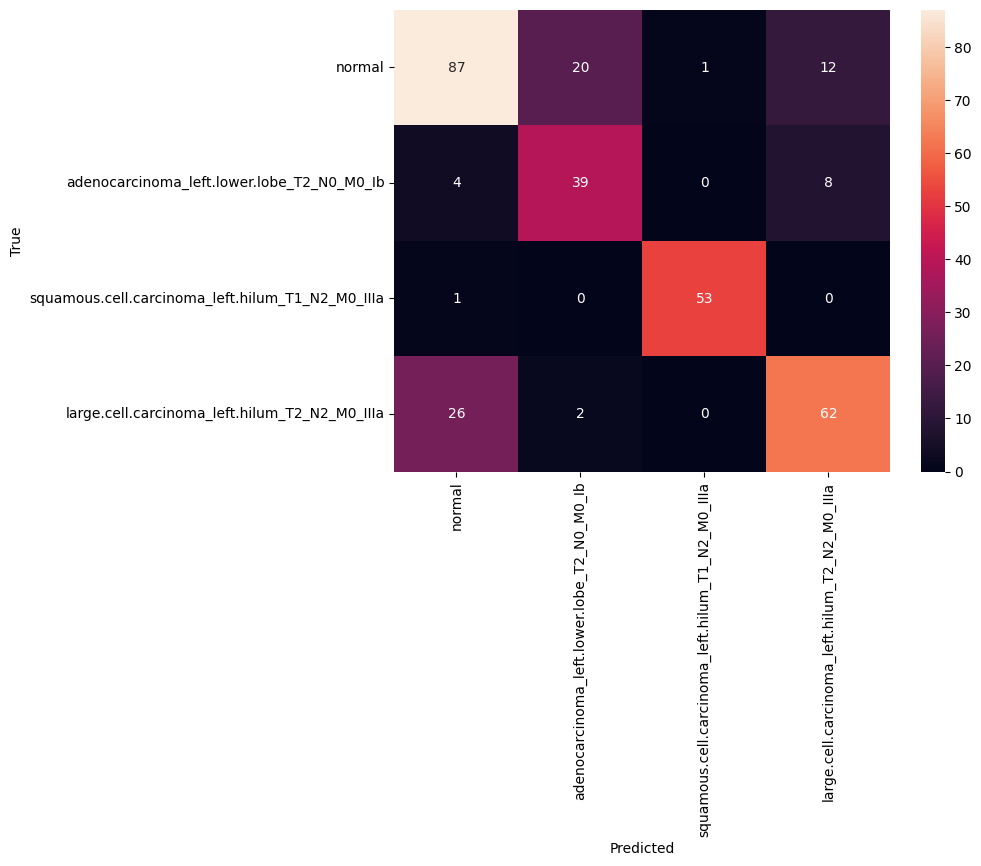

                                                  precision    recall  f1-score   support

                                          normal       0.74      0.72      0.73       120
      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.64      0.76      0.70        51
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.98      0.98      0.98        54
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.76      0.69      0.72        90

                                        accuracy                           0.77       315
                                       macro avg       0.78      0.79      0.78       315
                                    weighted avg       0.77      0.77      0.77       315



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Prédictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

## C'est beaucoup mieux !
- On a corrigé beaucoup d'erreurs pour adenocarcinoma ( 41% a 76% )
- perte pour le cancer normal ( pas grave seulement 13 erreurs)
- Je trouve les deux autres largement satisfaisants

Sauvegarde de ce modèle dans le drive

In [ ]:
model.save("/content/drive/MyDrive/lung_model_optimized_2.keras")

In [ ]:
Bloc pour le recharger

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/lung_model_optimized_2.keras"
)

C'etait le dernier entrainement :)

# Entrainement fini :) !


## Voici mon projet fonctionel (Executer d'abord les codes ci dessous)

API de Kaggle

In [ ]:
from google.colab import userdata
import json, os

kaggle_key = userdata.get('API_KAGGLE')
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": "pataplouf", "key": kaggle_key}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

Chargement de la base de données d'IRM de poumons

In [ ]:
!kaggle datasets download -d mohamedhanyyy/chest-ctscan-images
!unzip chest-ctscan-images.zip

In [ ]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/Data/train",
    image_size=(224,224),
    batch_size=32,
    label_mode="categorical"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/Data/valid",
    image_size=(224,224),
    batch_size=32,
    label_mode="categorical"
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/Data/test",
    image_size=(224,224),
    batch_size=32,
    label_mode="categorical"
)

Found 613 files belonging to 4 classes.
Found 72 files belonging to 4 classes.
Found 315 files belonging to 4 classes.


Connexion a mon drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/lung_model_optimized_2.keras"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Code final :)

Saving 000155.png to 000155.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


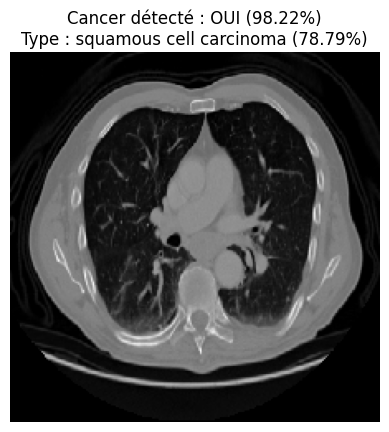

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.preprocessing import image

# Classes
class_names = [
    "normal",
    "adenocarcinoma",
    "squamous cell carcinoma",
    "large cell carcinoma"
]

# Choix de l'image
uploaded = files.upload()

for filename in uploaded.keys():

    # Chargement de l'image
    img = image.load_img(filename, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # DenseNet
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)

    # Prediction
    predictions = model.predict(img_array)
    probs = predictions[0]

    class_index = np.argmax(probs)
    normal_index = class_names.index("normal")

    # Proba globale de cancer
    cancer_probability = (1 - probs[normal_index]) * 100

    # Affichage
    plt.imshow(img)
    plt.axis("off")


    if class_index == normal_index:
        result_text = f"Pas de cancer ({probs[normal_index]*100:.2f}%)"
    else:
        type_confidence = probs[class_index] * 100

        result_text = (
            f"Cancer détecté : OUI ({cancer_probability:.2f}%)\n"
            f"Type : {class_names[class_index]} ({type_confidence:.2f}%)"
        )

    plt.title(result_text)
    plt.show()
